# Compact production-shaped FX signal pipeline

Полноценный альтернативный pipeline для прямого сравнения с `prod_pipline.ipynb`. Он использует те же данные, targets `G0/W1` и определения lift/BPS, но заменяет массовый поиск на шесть простых rule-движков, pooled ML и один заменяемый selector.

Все границы выводятся из доступной истории: `36m rolling train → causal OOS warm-up → selector validation → один финальный holdout`. Конкретные даты печатаются перед результатами и не зашиты в алгоритм.

In [1]:
from datetime import date
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((
    p.resolve() for p in candidate_roots
    if (p / 'src' / 'cbr_loader.py').is_file()
), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Не найден корень prod с папкой src')
project_root_str = str(PROJECT_ROOT)
# VS Code может добавить research/yura в sys.path раньше prod и тогда
# имя src ошибочно разрешается как research/yura/src. Корень prod всегда
# должен находиться первым; также очищаем неверный cache текущего kernel.
sys.path = [item for item in sys.path if item != project_root_str]
sys.path.insert(0, project_root_str)
cached_src = sys.modules.get('src')
expected_src = (PROJECT_ROOT / 'src').resolve()
if cached_src is not None:
    cached_file = Path(getattr(cached_src, '__file__', '') or '.').resolve()
    if expected_src not in cached_file.parents:
        for module_name in [name for name in tuple(sys.modules) if name == 'src' or name.startswith('src.')]:
            del sys.modules[module_name]

from src.cbr_loader import CURRENCIES, load_cbr_history
from src.features import build_features
from src.market_data import build_daily_market_panel
from src.outcomes import add_future_outcomes
from src.visualization import (
    plot_policy_bootstrap_intervals, plot_policy_currency_overview,
    plot_policy_horizon_heatmaps,
    plot_signal_series,
)
from research.yura.src.config import YuraPipelineConfig
from research.yura.src.models import ML_FEATURES
from research.yura.src.rules import RULE_LIBRARY
from research.yura.src.targets import build_yura_targets
from research.yura.src.pipeline import run_yura_pipeline
from research.yura.src.reporting import compare_backtest_summaries
from research.yura.src.visualization import (
    plot_holdout_horizon_mix, plot_holdout_sequential_metrics,
    plot_source_contribution, plot_validation_frontier,
)

START_DATE = date(2018, 1, 1)
END_DATE = date.today()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'cbr'
CONFIG = YuraPipelineConfig()
CONFIG

YuraPipelineConfig(currencies=('AMD', 'KZT', 'KGS', 'TJS', 'UZS'), target_families=('G0', 'W1'), horizons=(1, 3, 5, 10, 20), base_oos_start=None, arbiter_validation_start=None, holdout_start=None, train_months=36, retrain_months=6, rule_confidence_months=24, rule_confidence_prior_strength=20.0, confidence_warmup_months=12, selector_validation_months=36, relative_rank_months=36, w1_forward_bps=20.0, rule_min_signals_per_week=0.5, rule_max_signals_per_week=4.0, ml_learning_rate=0.06, ml_max_iter=80, ml_max_leaf_nodes=7, ml_min_samples_leaf=30, ml_l2_regularization=2.0, random_state=42, rule_lift_thresholds=(1.3,), ml_lift_thresholds=(1.3,), min_expected_bps_options=(0.0,), decision_score_thresholds=(0.0,), cooldown_options=(2,), max_signals_per_7d=2, min_average_signals_per_week=1.0, max_average_signals_per_week=2.0, validation_quarterly_lift_floor=1.3)

## 1. Данные, causal features и labels

Вход полностью совпадает с основным pipeline. `available_at` — фактическая граница доступности строки. Future outcomes ниже являются только labels для созревших исторических наблюдений и никогда не входят в `ML_FEATURES`.

In [2]:
cbr_history = load_cbr_history(
    start_date=START_DATE, end_date=END_DATE, currencies=CURRENCIES, raw_dir=RAW_DIR,
)
rates = (
    cbr_history.pivot(index='available_at', columns='currency', values='normalized_rate')
    .reindex(columns=list(CURRENCIES)).sort_index()
)
rates.columns.name = None
market_panel = build_daily_market_panel(rates)
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=CONFIG.horizons)
dataset, target_registry = build_yura_targets(
    outcomes, horizons=CONFIG.horizons,
    w1_forward_bps=CONFIG.w1_forward_bps,
)
scoring_data = dataset.loc[
    dataset['is_update_day'] & dataset['currency'].isin(CONFIG.currencies)
].copy()

assert not any(name.startswith('target_') for name in ML_FEATURES)
pd.DataFrame({
    'first_available_at': [scoring_data['available_at'].min()],
    'last_available_at': [scoring_data['available_at'].max()],
    'rows': [len(scoring_data)],
    'currencies': [', '.join(CONFIG.currencies)],
})

,first_available_at,last_available_at,rows,currencies
0,2018-01-11,2026-09-06,10690,"AMD, KZT, KGS, TJS, UZS"


## 2. Замороженная архитектура

Шесть rule-идей — самостоятельные интерпретируемые движки. Два небольших pooled ML-классификатора дают вероятности для `G0` и нового forward-window `W1` сразу по всем валютам и горизонтам, а одна pooled regression оценивает ожидаемый BPS. Deterministic evidence-слой ничего не обучает: он лишь приводит выходы движков к единому контракту. Relative ranks считаются в causal rolling-окне 36 месяцев. Затем заменяемый selector отвечает только за качество, а отдельная policy — только за cooldown и hard cap.

In [3]:
architecture = pd.DataFrame([
    {'rule_engine': name, 'parameter_variants': len(variants),
     'features': ', '.join(sorted({item.feature for item in variants}))}
    for name, variants in RULE_LIBRARY.items()
]).sort_values('rule_engine').reset_index(drop=True)
architecture

,rule_engine,parameter_variants,features
0,high_volatility,4,volatility_ratio_7d_30d
1,level_low,16,"percentile_180d, percentile_30d, percentile_60..."
2,momentum_down,20,"return_10d_bps, return_1d_bps, return_20d_bps,..."
3,near_low,12,"distance_from_low_180d_bps, distance_from_low_..."
4,reversal,12,"bounce_from_prior_low_120d_bps, bounce_from_pr..."
5,trend_down,9,"slope_10d_bps_per_day, slope_3d_bps_per_day, s..."


## 3. Полный walk-forward и финальный pipeline

Это единственная тяжелая ячейка. До каждой даты переобучения используются только последние 36 месяцев и только labels, для которых строго выполнено `available_at + horizon < retrain_at`. ML probability калибруется на последнем шестимесячном блоке прошлого. Selector видит только свой validation-интервал; после его окончания конфигурация замораживается и единожды применяется к следующему holdout.

In [4]:
result = run_yura_pipeline(
    scoring_data, target_registry=target_registry, config=CONFIG,
)
display(result.temporal_plan.as_frame())
print(f"Selector: {result.selector_name}")
print(f"Base candidates: {len(result.base_replay.candidates):,}")
print(f"Final holdout signals: {len(result.final_signals):,}")
result.fitted_arbiter

,data_start,data_end,base_oos_start,selector_validation_start,selector_validation_end,holdout_start,maximum_horizon_days
0,2018-01-01,2026-09-06,2021-01-01,2022-01-01,2025-01-01,2025-01-01,20


Selector: ThresholdSelector
Base candidates: 223,562
Final holdout signals: 535


FittedArbiter(config=ArbiterConfig(rule_min_lift=1.3, ml_min_lift=1.3, min_expected_bps=0.0, min_decision_score=0.0, cooldown_days=2, max_signals_per_7d=2), validation_start=Timestamp('2022-01-01 00:00:00'), validation_end=Timestamp('2025-01-01 00:00:00'), validation_geometric_lift=1.692354311919198, validation_macro_lift=1.694187990274434, validation_min_currency_lift=1.6148092191691725, validation_macro_benefit_uplift_bps=66.9724387002988, validation_mean_signals_per_week=1.1852054794520552, validation_quarterly_geometric_lift=1.747969505772079, validation_min_currency_quarterly_geometric_lift=1.5616362233605623, validation_quarterly_lift_p10=0.8912319522781177, validation_stability_ok=False, validation_scenario_coverage=1.0, validation_horizon_coverage=1.0)

## 4. Temporal audit

Таблица показывает каждый реальный refit. `trained_through + horizon` всегда строго раньше `retrain_at`; assertion этого условия также встроен в публичную функцию запуска.

In [5]:
training_audit = result.base_replay.audit.sort_values(
    ['retrain_at', 'target_family', 'horizon', 'engine_type', 'engine_name'],
    na_position='first',
).reset_index(drop=True)
training_audit.tail(30)

,retrain_at,target_family,horizon,engine_type,engine_name,fitted,architecture,probability_calibration,train_start,trained_through,...,selected_variant,score_signal_count,train_signal_count,train_true_positive,train_precision,train_random_precision,train_lift,train_min_currency_smoothed_lift,train_macro_currency_smoothed_lift,train_mean_benefit_bps
810,2026-07-01,W1,1,rule,reversal,True,NaN,NaN,2023-07-01,2026-06-28,...,reversal:bounce_from_prior_low_20d_bps:ge:75,245.0,2611.0,807.0,0.309077,0.297976,1.037256,1.002885,1.036834,-6.876112
811,2026-07-01,W1,1,rule,trend_down,True,NaN,NaN,2023-07-01,2026-06-28,...,trend_down:slope_10d_bps_per_day:le:-25,10.0,669.0,207.0,0.309417,0.297976,1.038397,1.004509,1.031912,8.414281
812,2026-07-01,W1,3,ml,pooled_hgb,True,pooled_currency_and_horizon,temporal_platt_last_refit_block,2023-07-01,2026-06-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
813,2026-07-01,W1,3,rule,high_volatility,True,NaN,NaN,2023-07-01,2026-06-27,...,high_volatility:volatility_ratio_7d_30d:ge:1.2,69.0,901.0,325.0,0.360710,0.330000,1.093062,1.004902,1.084494,-1.022279
814,2026-07-01,W1,3,rule,level_low,True,NaN,NaN,2023-07-01,2026-06-27,...,level_low:percentile_90d:le:0.05,0.0,730.0,252.0,0.345205,0.330000,1.046077,0.972818,1.041909,38.424394
815,2026-07-01,W1,3,rule,momentum_down,True,NaN,NaN,2023-07-01,2026-06-27,...,momentum_down:return_10d_bps:le:-200,5.0,756.0,273.0,0.361111,0.330000,1.094276,1.032137,1.079541,40.957353
816,2026-07-01,W1,3,rule,near_low,True,NaN,NaN,2023-07-01,2026-06-27,...,near_low:distance_from_low_90d_bps:le:100,0.0,733.0,246.0,0.335607,0.330000,1.016991,0.939849,1.023984,36.667681
817,2026-07-01,W1,3,rule,reversal,True,NaN,NaN,2023-07-01,2026-06-27,...,reversal:bounce_from_prior_low_20d_bps:ge:40,235.0,2851.0,953.0,0.334269,0.330000,1.012935,0.980874,1.012630,-11.442360
818,2026-07-01,W1,3,rule,trend_down,True,NaN,NaN,2023-07-01,2026-06-27,...,trend_down:slope_10d_bps_per_day:le:-25,10.0,669.0,238.0,0.355755,0.330000,1.078045,1.019633,1.066393,32.143418
819,2026-07-01,W1,5,ml,pooled_hgb,True,pooled_currency_and_horizon,temporal_platt_last_refit_block,2023-07-01,2026-06-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Validation selector

Стандартный `ThresholdSelector` — прозрачная отправная точка с общей конфигурацией для всех валют, targets и горизонтов. Validation не касается holdout и сохраняет полный audit качества, частоты и устойчивости. Команда может передать в `run_yura_pipeline(..., selector=...)` другую реализацию того же интерфейса; walk-forward движков, policy и backtest при этом не меняются.

In [6]:
result.arbiter_leaderboard.head(20)

,rule_min_lift,ml_min_lift,min_expected_bps,min_decision_score,cooldown_days,geometric_lift,macro_lift,min_currency_lift,macro_benefit_uplift_bps,mean_signals_per_week,...,quarterly_geometric_lift,min_currency_quarterly_geometric_lift,quarterly_lift_p10,quarterly_lift_std,scenario_coverage,horizon_coverage,coverage_ok,stability_ok,frequency_ok,selected
0,1.3,1.3,0.0,0.0,2,1.692354,1.694188,1.614809,66.972439,1.185205,...,1.74797,1.561636,0.891232,0.7405,1.0,1.0,True,False,True,True


## 6. Единственная финальная оценка на holdout

Математика совпадает с основным pipeline: 5 строк `currency`, 25 `currency+horizon` и 50 `currency+horizon+target_family`, всего 80 строк для `G0/W1`. `action_summary` отдельно оценивает уникальные клиентские действия по BPS и частоте — без математически некорректного смешивания двух разных target labels в одну precision.

In [7]:
signal_backtest_summary = result.backtest_summary
signal_backtest_rows = result.backtest_rows
final_signal_stream = result.final_signals
expected_summary_rows = (
    len(CONFIG.currencies)
    + len(CONFIG.currencies) * len(CONFIG.horizons)
    + len(CONFIG.currencies) * len(CONFIG.horizons) * len(CONFIG.target_families)
)
assert len(signal_backtest_summary) == expected_summary_rows
display(result.action_summary)
display(signal_backtest_summary)
display(result.holdout_coverage)
result.holdout_quarterly_stability

,currency,signal_count,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,AMD,104,86.142857,1.207297,53.676215,2.057635,51.618580,0.778846
1,KGS,111,86.142857,1.288557,44.464693,2.275957,42.188736,0.774775
2,KZT,108,86.142857,1.253731,56.294570,5.182756,51.111814,0.768519
3,TJS,105,86.142857,1.218905,55.474938,1.945580,53.529358,0.771429
4,UZS,107,86.142857,1.242123,59.976411,2.738138,57.238274,0.803738


,scope,currency,horizon,target_family,observations,positive_count,signal_count,true_positive,false_positive,precision,random_precision,lift,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,currency,AMD,ALL,ALL,4056,965,104,30,74,0.288462,0.133082,2.167551,86.142857,1.207297,53.676215,2.057635,51.618580,0.778846
1,currency,KGS,ALL,ALL,4056,911,111,29,82,0.261261,0.162033,1.612394,86.142857,1.288557,44.464693,2.275957,42.188736,0.774775
2,currency,KZT,ALL,ALL,4056,1073,108,34,74,0.314815,0.143098,2.199999,86.142857,1.253731,56.294570,5.182756,51.111814,0.768519
3,currency,TJS,ALL,ALL,4056,1031,105,37,68,0.352381,0.163993,2.148760,86.142857,1.218905,55.474938,1.945580,53.529358,0.771429
4,currency,UZS,ALL,ALL,4056,1035,107,30,77,0.280374,0.132830,2.110777,86.142857,1.242123,59.976411,2.738138,57.238274,0.803738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,currency+horizon+target_family,UZS,5,W1,407,162,0,0,0,0.000000,0.398034,0.000000,85.285714,0.000000,NaN,NaN,NaN,0.000000
76,currency+horizon+target_family,UZS,10,G0,404,16,14,4,10,0.285714,0.039604,7.214286,84.857143,0.164983,87.247592,2.333043,84.914550,0.857143
77,currency+horizon+target_family,UZS,10,W1,404,176,0,0,0,0.000000,0.435644,0.000000,84.857143,0.000000,NaN,NaN,NaN,0.000000
78,currency+horizon+target_family,UZS,20,G0,397,9,36,2,34,0.055556,0.022670,2.450617,83.285714,0.432247,85.785439,6.331283,79.454156,0.777778


,currency,scenario,target_family,horizon,signal_count
0,AMD,GOOD_NOW,G0,1,34
1,AMD,GOOD_NOW,G0,3,8
2,AMD,GOOD_NOW,G0,5,9
3,AMD,GOOD_NOW,G0,10,12
4,AMD,GOOD_NOW,G0,20,38
5,AMD,WINDOW_CLOSING,W1,1,2
6,AMD,WINDOW_CLOSING,W1,3,1
7,KGS,GOOD_NOW,G0,1,30
8,KGS,GOOD_NOW,G0,3,5
9,KGS,GOOD_NOW,G0,5,11


,currency,quarter,signal_count,precision,random_precision,lift,benefit_uplift_bps
0,AMD,2025Q1,22,0.181818,0.118213,1.538054,62.094155
1,AMD,2025Q2,20,0.200000,0.100541,1.989247,35.637885
2,AMD,2025Q3,13,0.307692,0.189174,1.626501,29.774640
3,AMD,2025Q4,16,0.312500,0.114038,2.740315,73.070023
4,AMD,2026Q1,9,0.666667,0.178595,3.732846,50.269543
5,AMD,2026Q2,18,0.111111,0.104417,1.064107,48.764559
6,AMD,2026Q3,6,0.833333,0.243044,3.428734,67.187421
7,KGS,2025Q1,22,0.227273,0.250290,0.908038,19.212619
8,KGS,2025Q2,21,0.142857,0.155845,0.916664,17.239033
9,KGS,2025Q3,14,0.214286,0.149508,1.433276,41.591227


### 6.1. Прямое сравнение с текущим pipeline

Обе таблицы имеют одинаковый 80-строчный контракт для G0/W1. Если `current_signal_backtest_summary` загружена в kernel либо прочитана из файла, следующая функция рассчитает сопоставимые дельты:

```python
comparison = compare_backtest_summaries(
    current_signal_backtest_summary, signal_backtest_summary
)
```

## 7. Диагностика base engines

Rule-таблица — реальные standalone-сигналы каждого простого индикатора. ML-таблица оценивает качество вероятностного score до policy через Brier и ROC AUC; ее нельзя напрямую сравнивать по precision с уже отфильтрованными rule-сигналами.

In [8]:
display(result.rule_baseline_summary.sort_values(
    ['currency', 'target_family', 'horizon', 'lift'],
    ascending=[True, True, True, False],
).head(30))
display(result.ml_score_diagnostics.sort_values(
    ['currency', 'target_family', 'horizon']
).head(30))

,currency,target_family,horizon,engine_name,signal_count,true_positive,precision,mean_causal_confidence,mean_random_precision,lift,mean_benefit_bps,positive_benefit_rate
2,AMD,G0,1,momentum_down:G0:h1,204,116,0.568627,0.555199,0.267613,2.124816,19.481078,0.789216
3,AMD,G0,1,near_low:G0:h1,85,40,0.470588,0.490142,0.265603,1.771772,18.106701,0.729412
1,AMD,G0,1,level_low:G0:h1,90,42,0.466667,0.486211,0.264395,1.765033,18.755577,0.733333
5,AMD,G0,1,trend_down:G0:h1,91,42,0.461538,0.461152,0.268733,1.717458,25.254849,0.780220
0,AMD,G0,1,high_volatility:G0:h1,249,67,0.269076,0.275175,0.268488,1.002190,-0.460594,0.493976
4,AMD,G0,1,reversal:G0:h1,295,65,0.220339,0.219119,0.269813,0.816637,-6.083874,0.416949
9,AMD,G0,3,near_low:G0:h3,85,26,0.305882,0.345850,0.127626,2.396716,37.637668,0.764706
8,AMD,G0,3,momentum_down:G0:h3,88,27,0.306818,0.321543,0.128180,2.393652,62.025021,0.897727
11,AMD,G0,3,trend_down:G0:h3,72,21,0.291667,0.317878,0.128061,2.277553,67.330750,0.888889
7,AMD,G0,3,level_low:G0:h3,90,25,0.277778,0.315589,0.127237,2.183153,42.705945,0.777778


,currency,target_family,horizon,engine_name,observations,positive_rate,mean_probability,brier_score,roc_auc
0,AMD,G0,1,pooled_hgb_G0_all_horizons,411,0.282238,0.265203,0.128903,0.861631
1,AMD,G0,3,pooled_hgb_G0_all_horizons,409,0.129584,0.127783,0.082387,0.889389
2,AMD,G0,5,pooled_hgb_G0_all_horizons,407,0.098280,0.093811,0.069516,0.892098
3,AMD,G0,10,pooled_hgb_G0_all_horizons,404,0.049505,0.050127,0.042628,0.904948
4,AMD,G0,20,pooled_hgb_G0_all_horizons,397,0.022670,0.029370,0.021168,0.921249
5,AMD,W1,1,pooled_hgb_W1_all_horizons,411,0.279805,0.328297,0.211586,0.494727
6,AMD,W1,3,pooled_hgb_W1_all_horizons,409,0.308068,0.338127,0.223411,0.485361
7,AMD,W1,5,pooled_hgb_W1_all_horizons,407,0.363636,0.348513,0.241662,0.493035
8,AMD,W1,10,pooled_hgb_W1_all_horizons,404,0.410891,0.356340,0.255715,0.500633
9,AMD,W1,20,pooled_hgb_W1_all_horizons,397,0.433249,0.366199,0.259878,0.523902


## 8. Визуализации

Все графики используют уже рассчитанные объекты — тяжелую ячейку повторять не нужно.

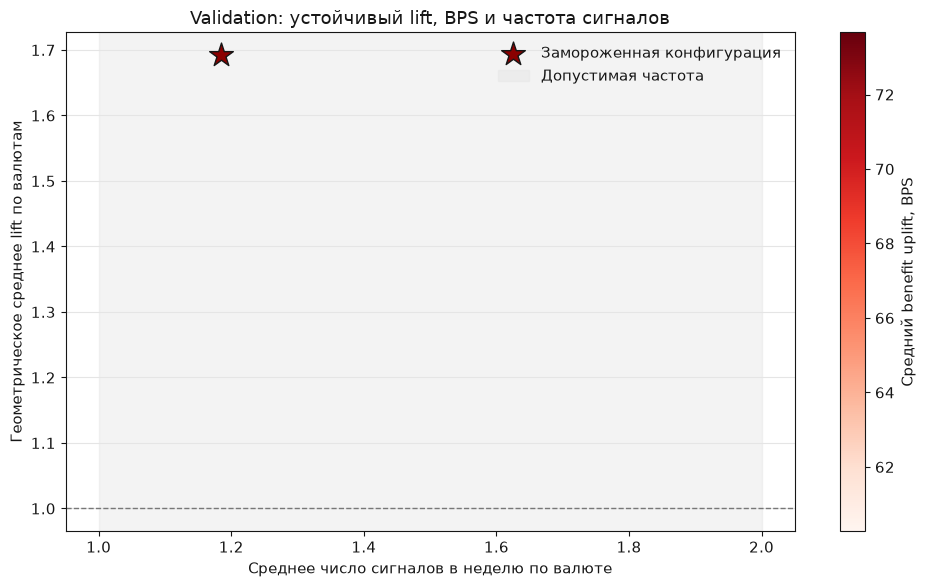

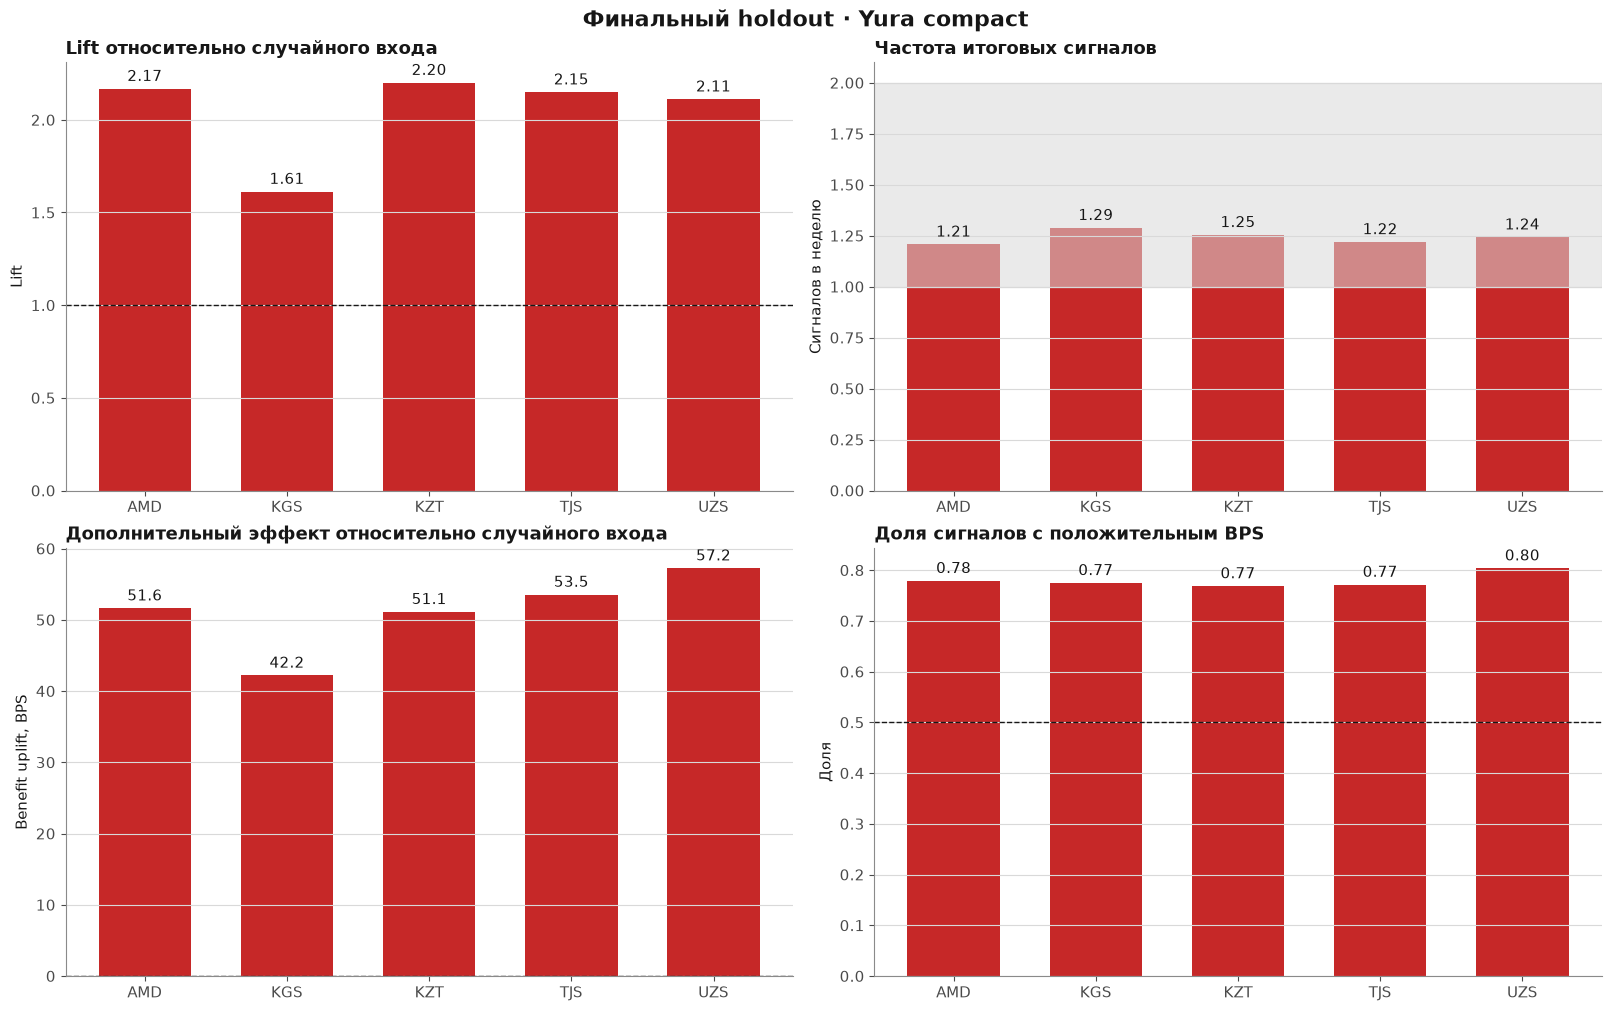

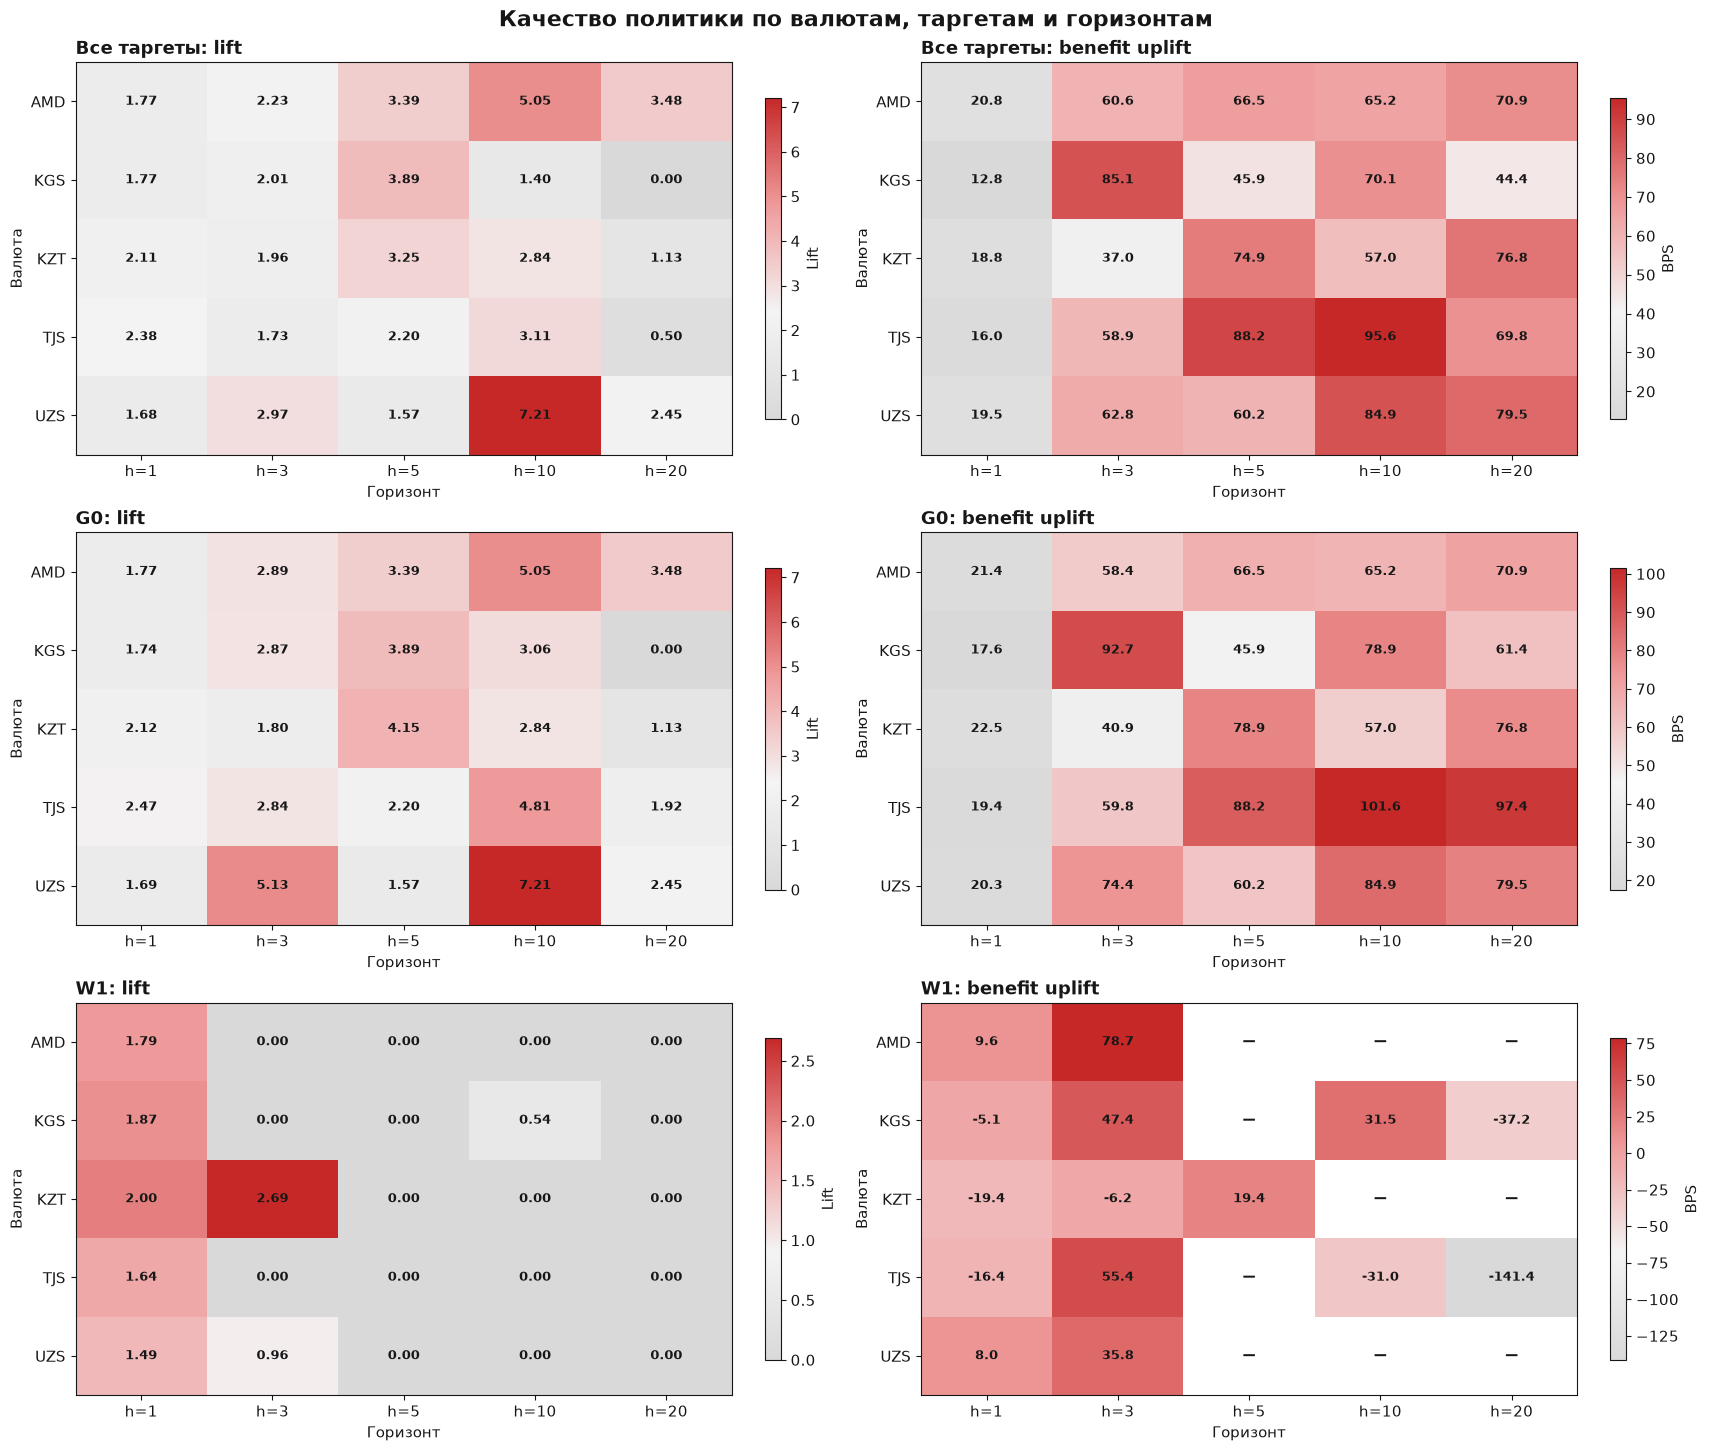

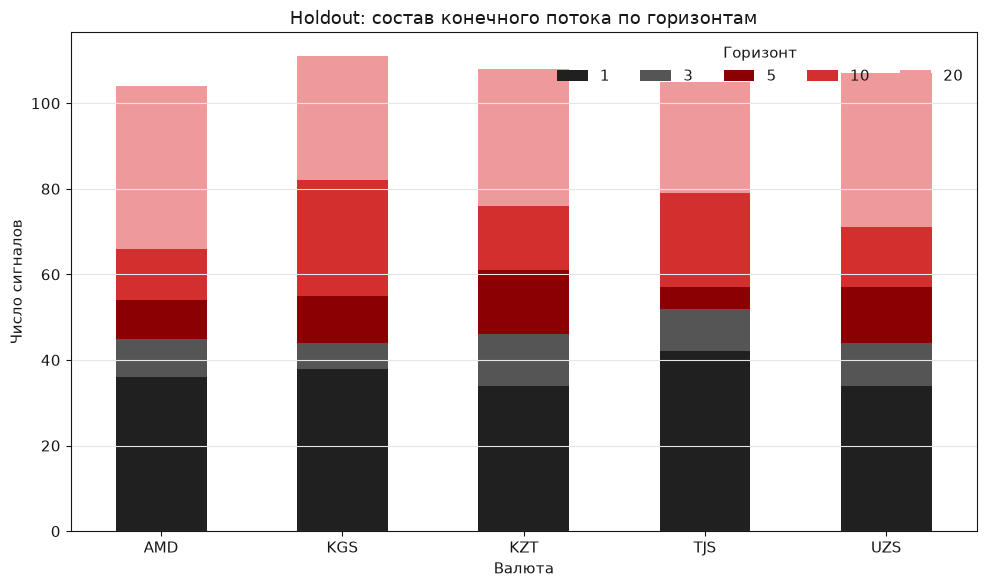

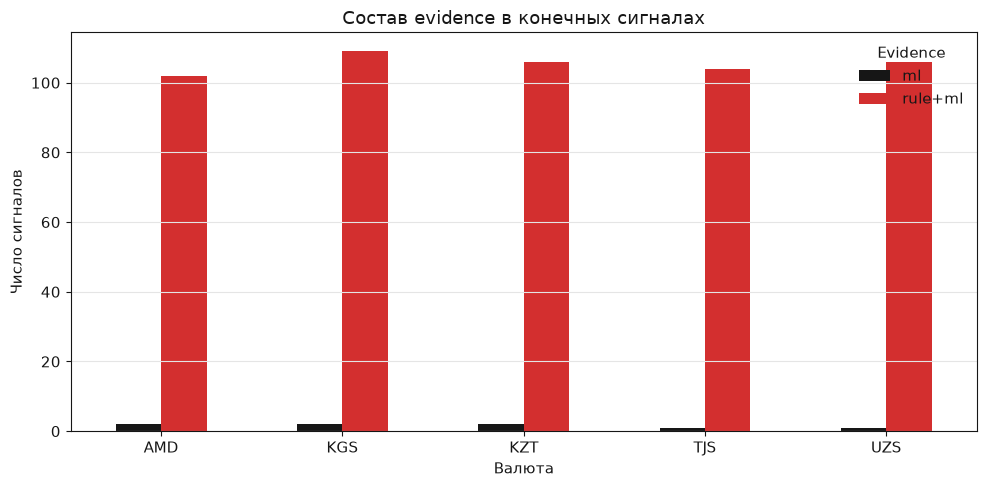

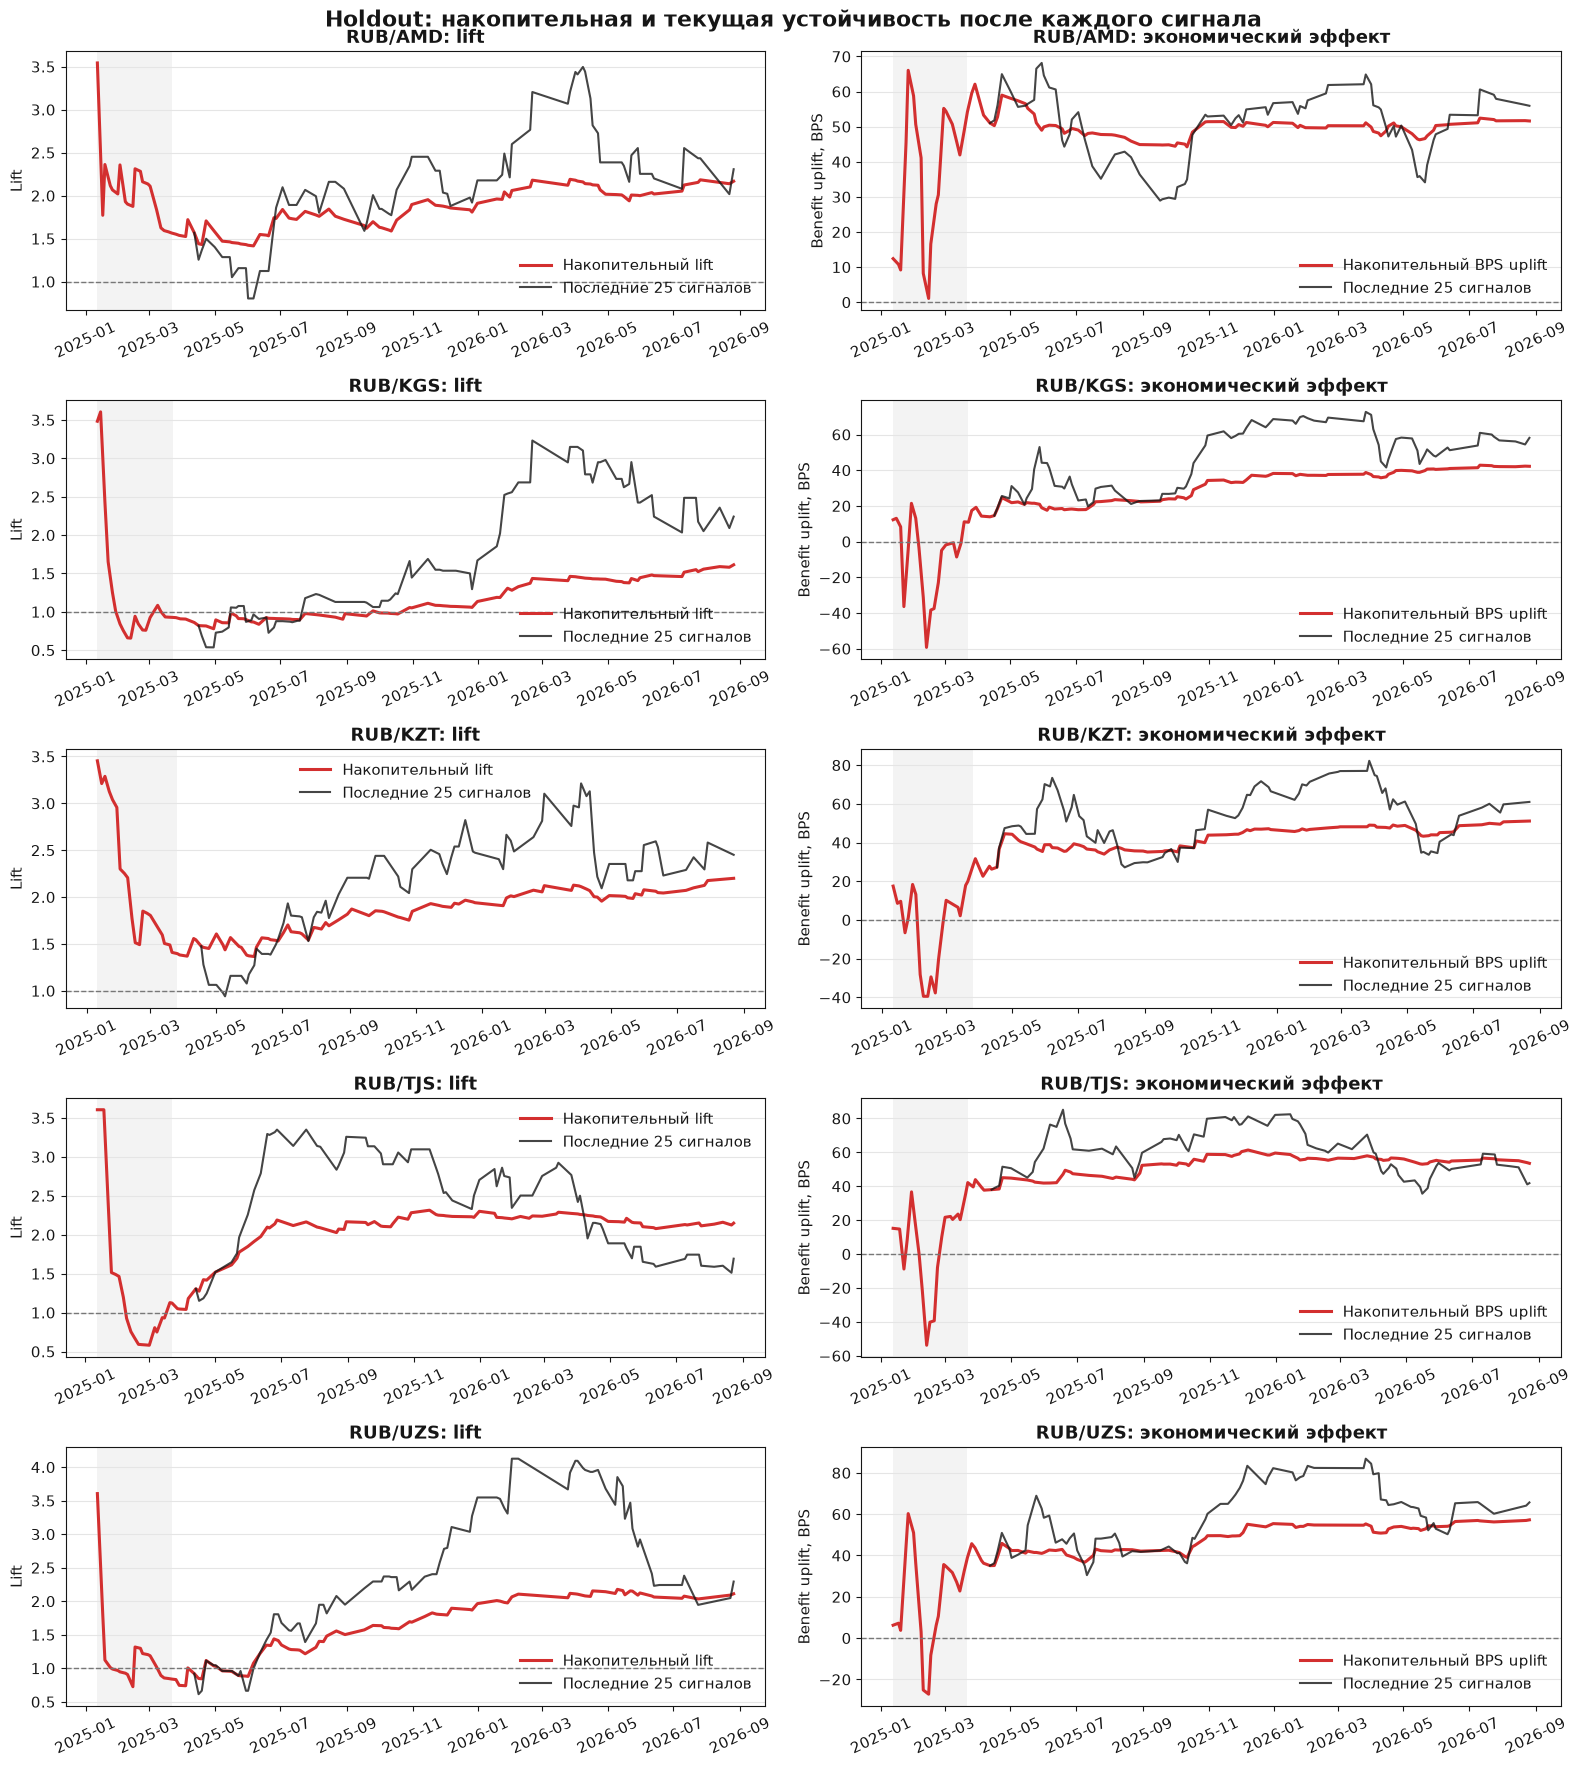

In [9]:
plot_validation_frontier(result.arbiter_leaderboard)
plt.show()

plot_policy_currency_overview(signal_backtest_summary, policy_name='Yura compact')
plt.show()

plot_policy_horizon_heatmaps(
    signal_backtest_summary, target_families=CONFIG.target_families,
)
plt.show()

plot_holdout_horizon_mix(final_signal_stream)
plt.show()

plot_source_contribution(final_signal_stream)
plt.show()

plot_holdout_sequential_metrics(
    signal_backtest_rows, rolling_signals=25, warmup_signals=20,
)
plt.show()

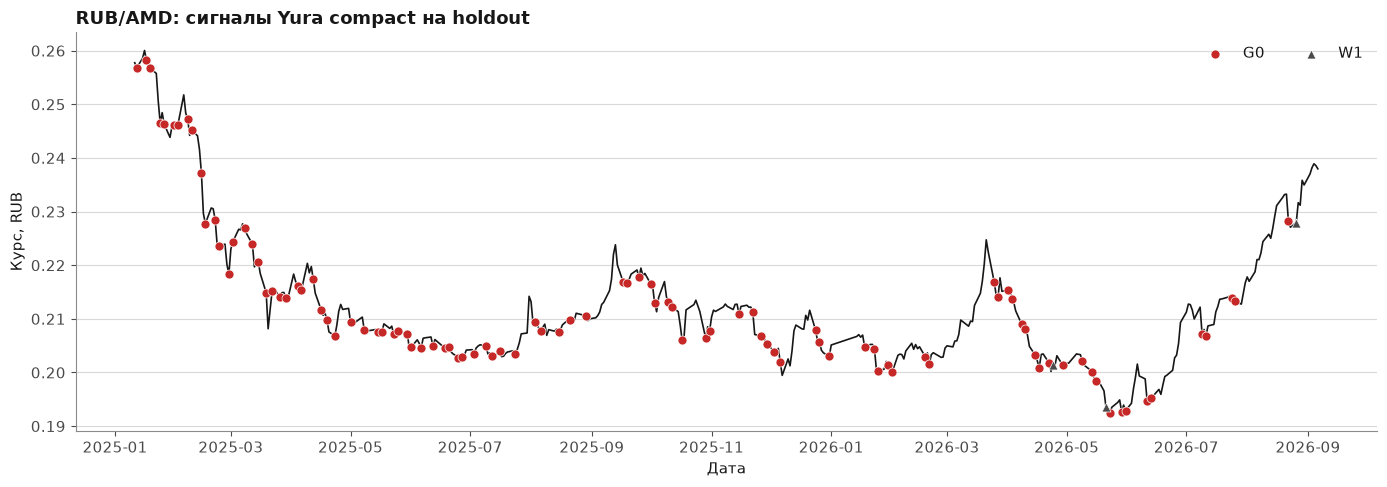

In [10]:
PRESENTATION_CURRENCY = 'AMD'
plot_signal_series(
    scoring_data, final_signal_stream, currency=PRESENTATION_CURRENCY,
    start_date=result.temporal_plan.holdout_start,
    title=f'RUB/{PRESENTATION_CURRENCY}: сигналы Yura compact на holdout',
)
plt.tight_layout()
plt.show()